In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Step 1: Load the dataset
data = pd.read_csv("housing.csv")
print("First 5 rows of the dataset:")
display(data.head())

First 5 rows of the dataset:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
# Step 2: Select features and target variable
X = data[['Avg. Area House Age', 'Avg. Area Income', 'Avg. Area Number of Rooms']]  # Multiple features
y = data['Price']  # Target variable

In [4]:
# Step 3: Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardizing features

In [5]:
# Step 4: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
# Step 5: Train linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Step 6: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

LinearRegression()

In [8]:
# Step 7: Ridge Regression (Regularization)
ridge = Ridge()
ridge_params = {'alpha': [0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5)
ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(), param_grid={'alpha': [0.1, 1, 10, 100]})

In [9]:
# Step 8: Lasso Regression (Regularization)
lasso = Lasso()
lasso_params = {'alpha': [0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5)
lasso_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=Lasso(), param_grid={'alpha': [0.1, 1, 10, 100]})

In [10]:
models = {
    'Linear Regression': linear_model,
    'Polynomial Regression': poly_model,
    'Ridge Regression': ridge_grid.best_estimator_,
    'Lasso Regression': lasso_grid.best_estimator_
}

for name, model in models.items():
    if name == 'Polynomial Regression':
        y_pred = model.predict(X_poly_test)
    else:
        y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, R2: {r2:.2f}")

Linear Regression - MSE: 31169684086.54, R2: 0.75
Polynomial Regression - MSE: 31080174542.56, R2: 0.75
Ridge Regression - MSE: 31178107852.86, R2: 0.75
Lasso Regression - MSE: 31172160479.40, R2: 0.75


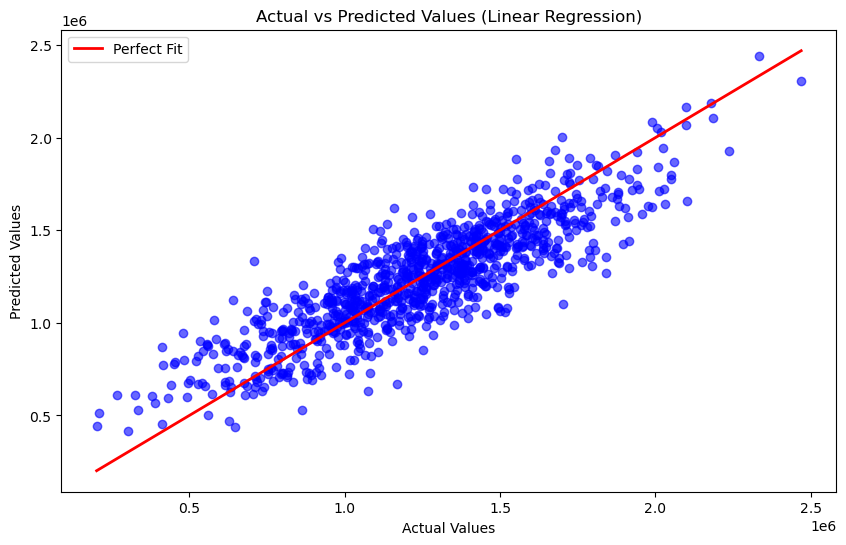

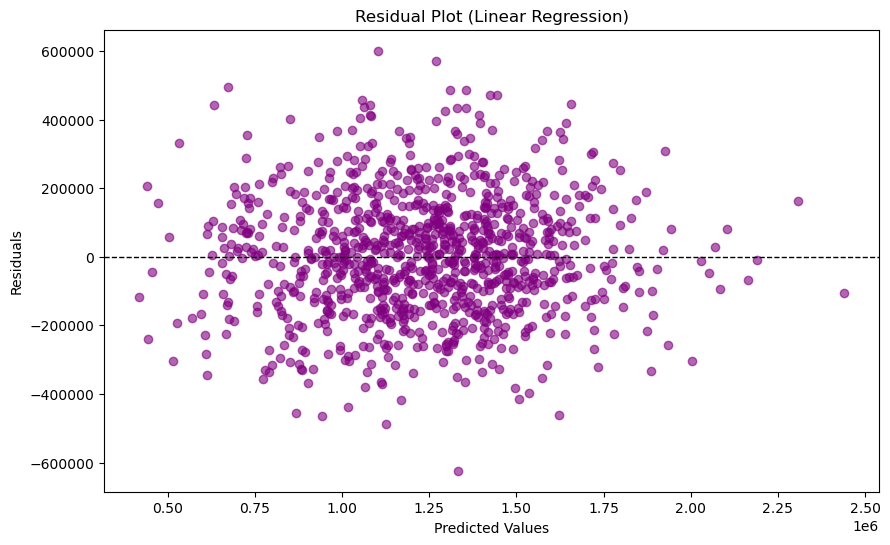

In [11]:
y_pred_linear = linear_model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Perfect Fit')
plt.title('Actual vs Predicted Values (Linear Regression)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

# Residual Plot
residuals = y_test - y_pred_linear
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_linear, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()